In [20]:
%pip install numpy pandas seaborn torch torchvision scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../house-prices-advanced-regression-techniques/train.csv")

X = df["GrLivArea"].values.reshape(-1, 1)
y = df["SalePrice"].values.reshape(-1, 1)

print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

(1460, 1) (1460, 1)


# Scratch

In [23]:
class PolyRegressionScratch:
    """
    Custom implementation of quadratic regression (degree 2) using gradient descent.
    """

    def __init__(self, alpha=1e-3, iterations=1000):
        self.a2 = 1  # coef of x^2
        self.a1 = 1  # coef of x
        self.a0 = 1  # intercept
        self.alpha = alpha
        self.iterations = iterations

    def predict(self, x):
        return self.a2 * x**2 + self.a1 * x + self.a0

    # Cost function (MSE)
    def compute_cost(self, x, y):
        m = len(x)
        predictions = self.predict(x)
        cost = (1 / m) * np.sum((predictions - y) ** 2)
        return cost

    def fit(self, x, y):
        m = len(x)

        for i in range(self.iterations):
            predictions = self.predict(x)

            # Gradients
            dJ_da0 = (2 / m) * np.sum(predictions - y)
            dJ_da1 = (2 / m) * np.sum((predictions - y) * x)
            dJ_da2 = (2 / m) * np.sum((predictions - y) * x**2)

            # Update coefficients
            self.a0 -= self.alpha * dJ_da0
            self.a1 -= self.alpha * dJ_da1
            self.a2 -= self.alpha * dJ_da2

            if i % 100 == 0:
                cost = self.compute_cost(x, y)
                r2 = r2_score(y, predictions)
                print(f"Iteration {i}, MSE: {cost}, R^2: {r2}")

        print(f"Optimized a0 (Intercept): {self.a0}")
        print(f"Optimized a1 (coef of x): {self.a1}")
        print(f"Optimized a2 (coef of x^2): {self.a2}")


In [24]:
alpha = 0.01
iterations = 1000

model = PolyRegressionScratch(alpha=alpha, iterations=iterations)
model.fit(X_scaled_train, y_train)

Iteration 0, MSE: 35465452889.91096, R^2: -5.519291072827268
Iteration 100, MSE: 4405062107.115227, R^2: 0.25491646458066697
Iteration 200, MSE: 3098004649.9892464, R^2: 0.48014996089591955
Iteration 300, MSE: 3002408383.9618864, R^2: 0.4965884451084941
Iteration 400, MSE: 2994558017.522348, R^2: 0.497937663343751
Iteration 500, MSE: 2993895802.8716598, R^2: 0.49805146320579186
Iteration 600, MSE: 2993839622.7887673, R^2: 0.49806111737767367
Iteration 700, MSE: 2993834851.0029006, R^2: 0.4980619373731594
Iteration 800, MSE: 2993834445.6005735, R^2: 0.49806200703842707
Iteration 900, MSE: 2993834411.1565695, R^2: 0.4980620129573625
Optimized a0 (Intercept): 185392.80214971965
Optimized a1 (coef of x): 59349.4071726915
Optimized a2 (coef of x^2): -3951.4921415707963


In [25]:
y_pred = model.predict(X_scaled_test)
y_train_pred = model.predict(X_scaled_train)
r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)

mse = mean_squared_error(y_test, y_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"R^2 on Train set: {r2_train}")
print(f"R^2 on Test set: {r2}")

print(f"MSE on Train set: {mse_train}")
print(f"MSE on Test set: {mse}")

R^2 on Train set: 0.49806201346025547
R^2 on Test set: 0.5332175703560227
MSE on Train set: 2993834408.2368727
MSE on Test set: 3580373503.15268


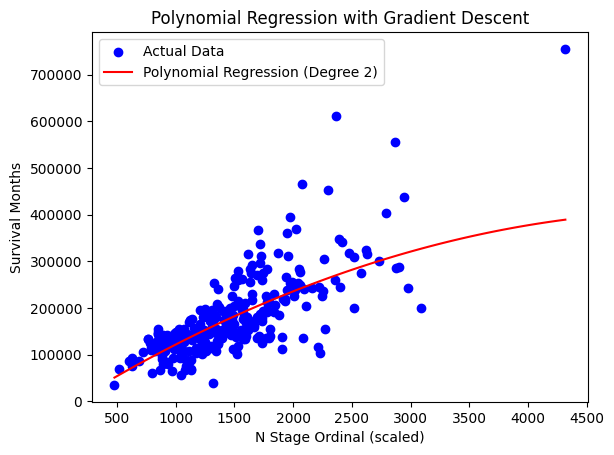

In [26]:
plt.scatter(X_test, y_test, color="blue", label="Actual Data")
X_range = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)
y_range_pred = model.predict(X_range_scaled)
plt.plot(X_range, y_range_pred, color="red", label="Polynomial Regression (Degree 2)")
plt.xlabel("N Stage Ordinal (scaled)")
plt.ylabel("Survival Months")
plt.title("Polynomial Regression with Gradient Descent")
plt.legend()
plt.show()

# Scikit-learn

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

degrees = list(range(1, 11))
train_r2_scores = []
test_r2_scores = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_scaled_train)
    X_test_poly = poly.transform(X_scaled_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    train_r2_scores.append(r2_train)
    test_r2_scores.append(r2_test)

    print(
        f"Degree {d}: R² train = {r2_train:.3f}, R² test = {r2_test:.3f}, MSE train = {mean_squared_error(y_train, y_train_pred):.3f}, MSE test = {mean_squared_error(y_test, y_test_pred):.3f}"
    )

Degree 1: R² train = 0.484, R² test = 0.554, MSE train = 3078116053.858, MSE test = 3418946311.181
Degree 2: R² train = 0.498, R² test = 0.533, MSE train = 2993834407.958, MSE test = 3580373007.104
Degree 3: R² train = 0.512, R² test = 0.543, MSE train = 2909488998.761, MSE test = 3504298719.383
Degree 4: R² train = 0.517, R² test = 0.556, MSE train = 2880816918.670, MSE test = 3407512391.378
Degree 5: R² train = 0.517, R² test = 0.560, MSE train = 2879283773.131, MSE test = 3377126980.154
Degree 6: R² train = 0.518, R² test = 0.557, MSE train = 2873013531.644, MSE test = 3397378253.819
Degree 7: R² train = 0.524, R² test = 0.574, MSE train = 2840715305.882, MSE test = 3265021586.696
Degree 8: R² train = 0.531, R² test = 0.591, MSE train = 2799469830.426, MSE test = 3139847406.107
Degree 9: R² train = 0.539, R² test = 0.591, MSE train = 2748418986.475, MSE test = 3137678601.049
Degree 10: R² train = 0.542, R² test = 0.591, MSE train = 2729344078.982, MSE test = 3137655414.663


R² Score: 0.5332
Mean Squared Error: 3580373007.10


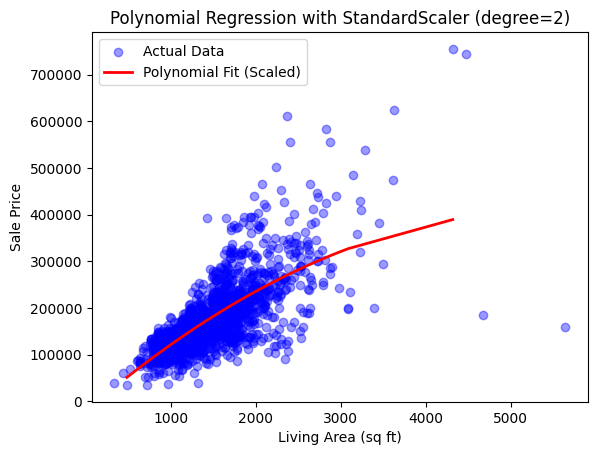

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linreg", LinearRegression()),
    ]
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

# Visualization
X_sorted, y_pred_sorted = zip(*sorted(zip(X_test.flatten(), y_pred)))
plt.scatter(X, y, color="blue", alpha=0.4, label="Actual Data")
plt.plot(
    X_sorted, y_pred_sorted, color="red", linewidth=2, label="Polynomial Fit (Scaled)"
)
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.title("Polynomial Regression with StandardScaler (degree=2)")
plt.legend()
plt.show()
